# Распознавание лиц с использованием Batch-Hard Triplet Loss

Этот ноутбук реализует обучение модели распознавания лиц на основе **метрического обучения**. В качестве базовой нейронной сети используется `ResNet18`, а итогом работы модели является компактный вектор признаков — **эмбеддинг лица**.

## Цель работы

Научить модель формировать такое пространство признаков, в котором:

- изображения одного человека располагаются близко друг к другу;
- изображения разных людей располагаются далеко друг от друга;
- ближайший сосед эмбеддинга с высокой вероятностью принадлежит тому же человеку.

## Используемые компоненты

- предобученная `ResNet18` как извлекатель признаков;
- 128-мерные L2-нормализованные эмбеддинги;
- `Batch-Hard Triplet Loss` для метрического обучения;
- вспомогательная классификационная голова с `CrossEntropyLoss`;
- balanced batches: несколько людей и несколько изображений каждого человека в одном батче;
- метрики `Classification Accuracy`, `Rank-1 Accuracy` и расстояния между эмбеддингами.

Общая функция потерь:

```text
Total Loss = CE_WEIGHT × CrossEntropy Loss
           + TRIPLET_WEIGHT × Batch-Hard Triplet Loss
```

`CrossEntropyLoss` помогает модели различать личности как классы, а `Triplet Loss` непосредственно формирует геометрию пространства эмбеддингов.


In [1]:
# Импорт библиотек и настройка воспроизводимости эксперимента.
# Один и тот же SEED фиксирует генераторы случайных чисел Python, NumPy и PyTorch.
# Это уменьшает разброс результатов между повторными запусками ноутбука.

import random
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import models, transforms
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.7.1+cu128
CUDA build: 12.8
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


## 1. Пути и гиперпараметры

В этой ячейке задаются:

- расположение подготовленного датасета;
- пути к выровненным и обрезанным изображениям;
- CSV-файлы обучающей и валидационной выборок;
- размер эмбеддинга и входного изображения;
- структура balanced batch;
- параметры оптимизатора, Triplet Loss и ранней остановки.

Перед запуском необходимо проверить значение `PROCESSED_DIR`. Оно должно указывать на папку, содержащую файлы `train_with_identity.csv`, `val_with_identity.csv`, `aligned_faces_all` и `cropped_faces`.


In [2]:
# Конфигурация эксперимента.
# PROCESSED_DIR необходимо изменить, если датасет расположен в другой папке.
# Все остальные пути формируются относительно этой директории.

PROCESSED_DIR = Path(
    r"D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new"
)

ALIGNED_DIR = PROCESSED_DIR / "aligned_faces_all"
CROPPED_DIR = PROCESSED_DIR / "cropped_faces"

TRAIN_CSV = PROCESSED_DIR / "train_with_identity.csv"
VAL_CSV = PROCESSED_DIR / "val_with_identity.csv"

OUTPUT_DIR = PROCESSED_DIR / "triplet_loss"
MODELS_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = MODELS_DIR / "triplet_best.pth"
HISTORY_CSV = OUTPUT_DIR / "triplet_training_history.csv"

NUM_CLASSES = 100
MAX_TRAIN_IMAGES_PER_CLASS = 30
MAX_VAL_IMAGES_PER_CLASS = 15

IMAGE_SIZE = (128, 128)
EMBEDDING_SIZE = 128

IDENTITIES_PER_BATCH = 8
IMAGES_PER_IDENTITY = 4

EPOCHS = 40
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

TRIPLET_MARGIN = 0.3
TRIPLET_WEIGHT = 1.0
CE_WEIGHT = 1.0

EARLY_STOPPING_PATIENCE = 10
NUM_WORKERS = 0

required_paths = [
    TRAIN_CSV,
    VAL_CSV,
    ALIGNED_DIR,
    CROPPED_DIR,
]

for path in required_paths:
    print(path.exists(), path)

missing = [str(path) for path in required_paths if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Не найдены обязательные файлы:\n" + "\n".join(missing)
    )


True D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\train_with_identity.csv
True D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\val_with_identity.csv
True D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\aligned_faces_all
True D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\cropped_faces


## 2. Подготовка данных

Сначала выбираются наиболее представленные личности из обучающей выборки. Это позволяет ограничить размер эксперимента и обеспечить достаточное число фотографий для каждого класса.

Для каждого изображения функция `resolve_image_path` сначала ищет выровненное лицо, а затем — обрезанное. Строки, для которых файл изображения отсутствует, удаляются.

Исходный `person_id` преобразуется в последовательную метку класса от `0` до `NUM_CLASSES - 1`. Классы, содержащие меньше двух обучающих изображений, исключаются, поскольку для Triplet Loss требуется хотя бы одна положительная пара.


In [3]:
# Формирование обучающей и валидационной таблиц.
# Выбираются наиболее представленные личности и только существующие файлы изображений.

def resolve_image_path(image_id):
    """Возвращает путь к изображению, отдавая приоритет выровненной версии лица."""
    aligned_path = ALIGNED_DIR / str(image_id)
    if aligned_path.exists():
        return aligned_path

    cropped_path = CROPPED_DIR / str(image_id)
    if cropped_path.exists():
        return cropped_path

    return None


train_full_df = pd.read_csv(TRAIN_CSV)
val_full_df = pd.read_csv(VAL_CSV)

top_person_ids = (
    train_full_df["person_id"]
    .value_counts()
    .head(NUM_CLASSES)
    .index
    .tolist()
)

label_mapping = {
    int(person_id): label
    for label, person_id in enumerate(top_person_ids)
}

train_df = train_full_df[
    train_full_df["person_id"].isin(top_person_ids)
].copy()

val_df = val_full_df[
    val_full_df["person_id"].isin(top_person_ids)
].copy()

train_df = (
    train_df
    .groupby("person_id", group_keys=False)
    .head(MAX_TRAIN_IMAGES_PER_CLASS)
    .reset_index(drop=True)
)

val_df = (
    val_df
    .groupby("person_id", group_keys=False)
    .head(MAX_VAL_IMAGES_PER_CLASS)
    .reset_index(drop=True)
)

train_df["image_path"] = train_df["image_id"].apply(resolve_image_path)
val_df["image_path"] = val_df["image_id"].apply(resolve_image_path)

train_df = train_df[train_df["image_path"].notna()].copy()
val_df = val_df[val_df["image_path"].notna()].copy()

train_df["label"] = train_df["person_id"].map(label_mapping).astype(int)
val_df["label"] = val_df["person_id"].map(label_mapping).astype(int)

train_counts = train_df["label"].value_counts()
valid_train_labels = set(train_counts[train_counts >= 2].index)

train_df = train_df[train_df["label"].isin(valid_train_labels)].copy()
val_df = val_df[val_df["label"].isin(valid_train_labels)].copy()

print(
    "Train:",
    len(train_df),
    "изображений,",
    train_df["label"].nunique(),
    "классов",
)

print(
    "Val:",
    len(val_df),
    "изображений,",
    val_df["label"].nunique(),
    "классов",
)

if train_df["label"].nunique() < IDENTITIES_PER_BATCH:
    raise RuntimeError("Недостаточно классов для balanced batch")


Train: 1196 изображений, 100 классов
Val: 77 изображений, 49 классов


In [4]:
# Аугментации, нормализация и класс Dataset.
# Аугментации применяются только к обучающим данным; validation остаётся детерминированной.

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class FaceIdentityDataset(Dataset):
    """PyTorch Dataset, возвращающий изображение, числовую метку и исходный image_id."""
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = cv2.imread(str(row["image_path"]))

        if image is None:
            raise FileNotFoundError(
                f"Не удалось прочитать: {row['image_path']}"
            )

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(int(row["label"]), dtype=torch.long)

        return image, label, str(row["image_id"])


train_dataset = FaceIdentityDataset(train_df, train_transform)
val_dataset = FaceIdentityDataset(val_df, val_transform)


## 3. Формирование сбалансированных батчей

Обычное случайное формирование батчей может привести к тому, что в одном батче окажется только по одному изображению каждого человека. В таком случае невозможно построить положительные пары для Triplet Loss.

`BalancedBatchSampler` формирует каждый батч по схеме:

```text
IDENTITIES_PER_BATCH людей × IMAGES_PER_IDENTITY изображений
```

Например, при значениях `8 × 4` один батч содержит 32 изображения: по четыре фотографии восьми разных людей. Это гарантирует наличие как положительных, так и отрицательных примеров.


In [5]:
# BalancedBatchSampler гарантирует несколько изображений каждой личности в батче.
# Это необходимо для корректного выбора positive и negative примеров в Triplet Loss.

class BalancedBatchSampler(Sampler):
    """Формирует батчи из P личностей и K изображений каждой личности."""
    def __init__(
        self,
        labels,
        identities_per_batch,
        images_per_identity,
        batches_per_epoch=None,
        seed=42,
    ):
        self.labels = np.asarray(labels)
        self.identities_per_batch = identities_per_batch
        self.images_per_identity = images_per_identity
        self.batch_size = identities_per_batch * images_per_identity
        self.seed = seed
        self.epoch = 0

        self.indices_by_label = defaultdict(list)

        for index, label in enumerate(self.labels):
            self.indices_by_label[int(label)].append(index)

        self.unique_labels = np.asarray(
            sorted(self.indices_by_label.keys())
        )

        if batches_per_epoch is None:
            batches_per_epoch = max(
                1,
                len(self.labels) // self.batch_size,
            )

        self.batches_per_epoch = batches_per_epoch

    def __len__(self):
        return self.batches_per_epoch

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)

        for _ in range(self.batches_per_epoch):
            selected_labels = rng.choice(
                self.unique_labels,
                size=self.identities_per_batch,
                replace=False,
            )

            batch_indices = []

            for label in selected_labels:
                class_indices = np.asarray(
                    self.indices_by_label[int(label)]
                )

                replace = (
                    len(class_indices) < self.images_per_identity
                )

                selected_indices = rng.choice(
                    class_indices,
                    size=self.images_per_identity,
                    replace=replace,
                )

                batch_indices.extend(selected_indices.tolist())

            rng.shuffle(batch_indices)
            yield batch_indices


train_batch_sampler = BalancedBatchSampler(
    labels=train_df["label"].to_numpy(),
    identities_per_batch=IDENTITIES_PER_BATCH,
    images_per_identity=IMAGES_PER_IDENTITY,
    seed=SEED,
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_batch_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 37
Val batches: 2


## 4. Архитектура модели

Модель состоит из двух частей:

1. **Embedding branch** — формирует 128-мерный вектор признаков лица.
2. **Classification branch** — предсказывает класс личности и используется только как вспомогательная задача во время обучения.

Последний классификационный слой исходной `ResNet18` удаляется. Полученный вектор признаков преобразуется линейным слоем в эмбеддинг заданной размерности, после чего выполняется L2-нормализация. Благодаря нормализации косинусное сходство становится эквивалентно скалярному произведению эмбеддингов.


In [6]:
# Нейронная сеть: ResNet18 извлекает признаки, embedding_head создаёт эмбеддинг,
# classifier используется как вспомогательная классификационная голова.

class TripletFaceModel(nn.Module):
    """ResNet18 с ветвью эмбеддингов и вспомогательным классификатором."""
    def __init__(self, num_classes, embedding_size=128):
        super().__init__()

        backbone = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        backbone_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone

        self.embedding_head = nn.Sequential(
            nn.Linear(backbone_features, embedding_size),
            nn.BatchNorm1d(embedding_size),
        )

        self.classifier = nn.Linear(
            embedding_size,
            num_classes,
        )

        self.embedding_size = embedding_size
        self.num_classes = num_classes

    def forward(self, images):
        features = self.backbone(images)
        raw_embeddings = self.embedding_head(features)

        embeddings = F.normalize(
            raw_embeddings,
            p=2,
            dim=1,
        )

        logits = self.classifier(raw_embeddings)

        return embeddings, logits


model = TripletFaceModel(
    num_classes=NUM_CLASSES,
    embedding_size=EMBEDDING_SIZE,
).to(DEVICE)

print(
    "Parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}",
)


Parameters: 11,255,332


## 5. Batch-Hard Triplet Loss

Для каждого anchor-изображения внутри батча выбираются:

- **hardest positive** — самое далёкое изображение того же человека;
- **hardest negative** — самое близкое изображение другого человека.

Функция потерь стремится выполнить условие:

```text
d(anchor, positive) + margin < d(anchor, negative)
```

Если условие уже выполнено, соответствующий triplet не вносит вклад в loss. Доля активных triplet-примеров показывает, насколько часто модель ещё нарушает заданный отступ `margin`.


In [7]:
# Реализация Batch-Hard Triplet Loss.
# Для каждого anchor выбираются наиболее сложные positive и negative внутри текущего батча.

class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        distances = torch.cdist(
            embeddings,
            embeddings,
            p=2,
        )

        labels = labels.view(-1)

        same_identity = labels[:, None] == labels[None, :]
        different_identity = ~same_identity

        diagonal = torch.eye(
            len(labels),
            dtype=torch.bool,
            device=labels.device,
        )

        positive_mask = same_identity & ~diagonal
        negative_mask = different_identity

        positive_distances = distances.masked_fill(
            ~positive_mask,
            float("-inf"),
        )

        hardest_positive = positive_distances.max(dim=1).values

        negative_distances = distances.masked_fill(
            ~negative_mask,
            float("inf"),
        )

        hardest_negative = negative_distances.min(dim=1).values

        valid = (
            torch.isfinite(hardest_positive)
            & torch.isfinite(hardest_negative)
        )

        if not valid.any():
            zero_loss = embeddings.sum() * 0.0

            return zero_loss, {
                "hardest_positive": 0.0,
                "hardest_negative": 0.0,
                "active_triplets": 0.0,
            }

        per_anchor_loss = F.relu(
            hardest_positive[valid]
            - hardest_negative[valid]
            + self.margin
        )

        loss = per_anchor_loss.mean()

        stats = {
            "hardest_positive": float(
                hardest_positive[valid].mean().detach().cpu()
            ),
            "hardest_negative": float(
                hardest_negative[valid].mean().detach().cpu()
            ),
            "active_triplets": float(
                (per_anchor_loss > 0)
                .float()
                .mean()
                .detach()
                .cpu()
            ),
        }

        return loss, stats


triplet_criterion = BatchHardTripletLoss(
    margin=TRIPLET_MARGIN
)

classification_criterion = nn.CrossEntropyLoss()


## 6. Метрики качества

Используются несколько взаимодополняющих показателей:

- **Classification Accuracy** — точность вспомогательной классификационной головы;
- **Rank-1 Accuracy** — доля примеров, для которых ближайший сосед относится к тому же человеку;
- **Mean positive distance** — среднее расстояние между лицами одного человека;
- **Mean negative distance** — среднее расстояние между лицами разных людей.

Хорошая модель должна уменьшать положительное расстояние и одновременно увеличивать отрицательное.


In [8]:
# Функции извлечения эмбеддингов и расчёта метрик на валидационной выборке.
# Все эмбеддинги уже L2-нормализованы, поэтому их скалярное произведение — cosine similarity.

@torch.inference_mode()
def collect_embeddings(model, loader):
    """Извлекает эмбеддинги, logits, labels и image_id для всего DataLoader."""
    model.eval()

    all_embeddings = []
    all_logits = []
    all_labels = []
    all_image_ids = []

    for images, labels, image_ids in tqdm(
        loader,
        desc="Validation",
        leave=False,
    ):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        embeddings, logits = model(images)

        all_embeddings.append(embeddings.cpu())
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())
        all_image_ids.extend(image_ids)

    return (
        torch.cat(all_embeddings).numpy(),
        torch.cat(all_logits).numpy(),
        torch.cat(all_labels).numpy(),
        all_image_ids,
    )


def classification_accuracy(logits, labels):
    """Возвращает долю правильных предсказаний классификационной головы."""
    predictions = np.argmax(logits, axis=1)
    return float(np.mean(predictions == labels))


def leave_one_out_rank1_accuracy(embeddings, labels):
    """Оценивает Rank-1, исключая совпадение каждого изображения с самим собой."""
    similarities = embeddings @ embeddings.T

    np.fill_diagonal(similarities, -np.inf)

    nearest_indices = np.argmax(similarities, axis=1)
    predictions = labels[nearest_indices]

    return float(np.mean(predictions == labels))


def mean_positive_negative_distance(embeddings, labels):
    """Считает средние расстояния для пар одного и разных людей."""
    similarities = embeddings @ embeddings.T

    distances = np.sqrt(
        np.maximum(0.0, 2.0 - 2.0 * similarities)
    )

    same = labels[:, None] == labels[None, :]
    diagonal = np.eye(len(labels), dtype=bool)

    positive_values = distances[same & ~diagonal]
    negative_values = distances[~same]

    return {
        "mean_positive_distance": (
            float(positive_values.mean())
            if len(positive_values)
            else np.nan
        ),
        "mean_negative_distance": (
            float(negative_values.mean())
            if len(negative_values)
            else np.nan
        ),
    }


## 7. Обучение модели

На каждой эпохе выполняются следующие шаги:

1. формирование balanced batch;
2. прямой проход через модель;
3. вычисление Triplet Loss и CrossEntropy Loss;
4. объединение двух функций потерь;
5. обратное распространение ошибки;
6. обновление весов оптимизатором `AdamW`;
7. оценка модели на валидационной выборке.

Для ускорения обучения на GPU используется automatic mixed precision. Лучшая модель сохраняется по значению `Validation Classification Accuracy`.


In [9]:
# Один полный проход обучения по balanced batches.
# Mixed precision используется только при наличии CUDA и уменьшает потребление видеопамяти.

@dataclass
class EpochResult:
    total_loss: float
    triplet_loss: float
    ce_loss: float
    train_accuracy: float
    hardest_positive: float
    hardest_negative: float
    active_triplets: float


def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    epoch,
):
    model.train()

    if hasattr(loader.batch_sampler, "set_epoch"):
        loader.batch_sampler.set_epoch(epoch)

    totals = defaultdict(float)
    sample_count = 0

    progress = tqdm(
        loader,
        desc=f"Epoch {epoch + 1}",
    )

    for images, labels, _ in progress:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        use_amp = DEVICE.type == "cuda"

        with torch.autocast(
            device_type=DEVICE.type,
            enabled=use_amp,
        ):
            embeddings, logits = model(images)

            triplet_loss, triplet_stats = triplet_criterion(
                embeddings,
                labels,
            )

            ce_loss = classification_criterion(
                logits,
                labels,
            )

            total_loss = (
                TRIPLET_WEIGHT * triplet_loss
                + CE_WEIGHT * ce_loss
            )

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)

        accuracy = (
            logits.argmax(dim=1) == labels
        ).float().mean()

        totals["total_loss"] += float(total_loss.detach().cpu()) * batch_size
        totals["triplet_loss"] += float(triplet_loss.detach().cpu()) * batch_size
        totals["ce_loss"] += float(ce_loss.detach().cpu()) * batch_size
        totals["accuracy"] += float(accuracy.detach().cpu()) * batch_size
        totals["hardest_positive"] += triplet_stats["hardest_positive"] * batch_size
        totals["hardest_negative"] += triplet_stats["hardest_negative"] * batch_size
        totals["active_triplets"] += triplet_stats["active_triplets"] * batch_size

        sample_count += batch_size

        progress.set_postfix(
            total=f"{total_loss.item():.4f}",
            triplet=f"{triplet_loss.item():.4f}",
            acc=f"{accuracy.item():.3f}",
        )

    return EpochResult(
        total_loss=totals["total_loss"] / sample_count,
        triplet_loss=totals["triplet_loss"] / sample_count,
        ce_loss=totals["ce_loss"] / sample_count,
        train_accuracy=totals["accuracy"] / sample_count,
        hardest_positive=totals["hardest_positive"] / sample_count,
        hardest_negative=totals["hardest_negative"] / sample_count,
        active_triplets=totals["active_triplets"] / sample_count,
    )


In [10]:
# Основной цикл обучения, валидация, scheduler, early stopping и сохранение checkpoint.
# Лучшая модель выбирается по максимальной validation classification accuracy.

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda"),
)

history = []
best_val_accuracy = -np.inf
best_rank1_accuracy = -np.inf
patience_counter = 0

for epoch in range(EPOCHS):
    train_result = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
        epoch,
    )

    (
        val_embeddings,
        val_logits,
        val_labels,
        val_image_ids,
    ) = collect_embeddings(
        model,
        val_loader,
    )

    val_accuracy = classification_accuracy(
        val_logits,
        val_labels,
    )

    val_rank1 = leave_one_out_rank1_accuracy(
        val_embeddings,
        val_labels,
    )

    distance_stats = mean_positive_negative_distance(
        val_embeddings,
        val_labels,
    )

    scheduler.step(val_accuracy)

    row = {
        "epoch": epoch + 1,
        "learning_rate": optimizer.param_groups[0]["lr"],
        "train_total_loss": train_result.total_loss,
        "train_triplet_loss": train_result.triplet_loss,
        "train_ce_loss": train_result.ce_loss,
        "train_accuracy": train_result.train_accuracy,
        "hardest_positive": train_result.hardest_positive,
        "hardest_negative": train_result.hardest_negative,
        "active_triplets": train_result.active_triplets,
        "val_accuracy": val_accuracy,
        "val_rank1": val_rank1,
        **distance_stats,
    }

    history.append(row)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_rank1_accuracy = val_rank1
        patience_counter = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_accuracy": val_accuracy,
            "val_rank1": val_rank1,
            "num_classes": NUM_CLASSES,
            "embedding_size": EMBEDDING_SIZE,
            "triplet_margin": TRIPLET_MARGIN,
            "triplet_weight": TRIPLET_WEIGHT,
            "ce_weight": CE_WEIGHT,
            "label_mapping": label_mapping,
        }, BEST_CHECKPOINT)

        print(
            f"Сохранена лучшая модель: "
            f"val_accuracy={val_accuracy:.4f}, "
            f"val_rank1={val_rank1:.4f}"
        )
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch + 1:02d}: "
        f"train_acc={train_result.train_accuracy:.4f}, "
        f"val_acc={val_accuracy:.4f}, "
        f"val_rank1={val_rank1:.4f}, "
        f"triplet={train_result.triplet_loss:.4f}, "
        f"pos_dist={distance_stats['mean_positive_distance']:.4f}, "
        f"neg_dist={distance_stats['mean_negative_distance']:.4f}"
    )

    pd.DataFrame(history).to_csv(
        HISTORY_CSV,
        index=False,
    )

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break

print("Best validation accuracy:", best_val_accuracy)
print("Best validation Rank-1:", best_rank1_accuracy)
print("Checkpoint:", BEST_CHECKPOINT)


Epoch 1:   0%|          | 0/37 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Сохранена лучшая модель: val_accuracy=0.1169, val_rank1=0.2078
Epoch 01: train_acc=0.1613, val_acc=0.1169, val_rank1=0.2078, triplet=0.5164, pos_dist=0.9918, neg_dist=1.2872


Epoch 2:   0%|          | 0/37 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 39: train_acc=0.9983, val_acc=0.9091, val_rank1=0.5195, triplet=0.0000, pos_dist=0.6572, neg_dist=1.4040


Epoch 40:   0%|          | 0/37 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Сохранена лучшая модель: val_accuracy=0.9351, val_rank1=0.5195
Epoch 40: train_acc=1.0000, val_acc=0.9351, val_rank1=0.5195, triplet=0.0000, pos_dist=0.6540, neg_dist=1.4049
Best validation accuracy: 0.935064935064935
Best validation Rank-1: 0.5194805194805194
Checkpoint: D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\triplet_loss\models\triplet_best.pth


## 8. Визуализация истории обучения

Графики позволяют оценить:

- сходимость общей и отдельных функций потерь;
- различие между обучающей и валидационной точностью;
- изменение Rank-1 Accuracy;
- разделение положительных и отрицательных расстояний.

Сильное расхождение между train и validation accuracy может свидетельствовать о переобучении.


,epoch,learning_rate,train_total_loss,train_triplet_loss,train_ce_loss,train_accuracy,hardest_positive,hardest_negative,active_triplets,val_accuracy,val_rank1,mean_positive_distance,mean_negative_distance
35,36,0.000037,0.027437,0.0,0.027437,0.999155,0.553513,1.405981,0.0,0.909091,0.519481,0.663572,1.410907
36,37,0.000037,0.025426,0.0,0.025426,1.000000,0.559286,1.399806,0.0,0.922078,0.519481,0.660678,1.409247
37,38,0.000019,0.025049,0.0,0.025049,1.000000,0.560436,1.402731,0.0,0.922078,0.519481,0.652911,1.406629
38,39,0.000019,0.028054,0.0,0.028054,0.998311,0.554837,1.401215,0.0,0.909091,0.519481,0.657215,1.403950
39,40,0.000019,0.026035,0.0,0.026035,1.000000,0.561926,1.405613,0.0,0.935065,0.519481,0.654033,1.404938


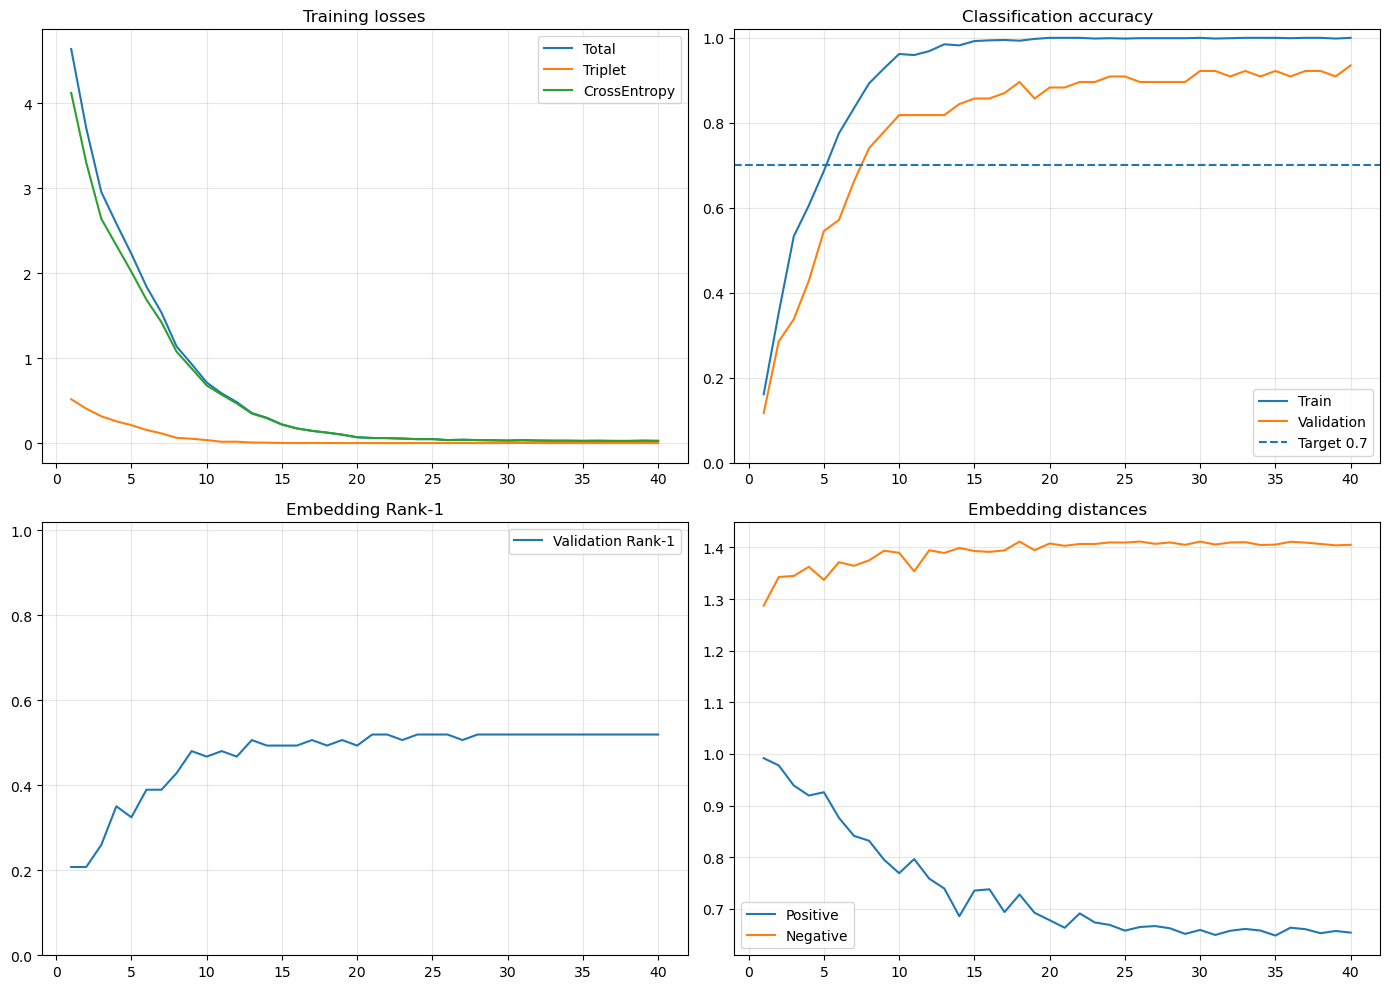

In [11]:
# Построение и сохранение графиков истории обучения.
# Графики позволяют одновременно анализировать loss, accuracy, Rank-1 и расстояния.

history_df = pd.DataFrame(history)
display(history_df.tail())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(
    history_df["epoch"],
    history_df["train_total_loss"],
    label="Total",
)
axes[0, 0].plot(
    history_df["epoch"],
    history_df["train_triplet_loss"],
    label="Triplet",
)
axes[0, 0].plot(
    history_df["epoch"],
    history_df["train_ce_loss"],
    label="CrossEntropy",
)
axes[0, 0].set_title("Training losses")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train",
)
axes[0, 1].plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation",
)
axes[0, 1].axhline(
    0.7,
    linestyle="--",
    label="Target 0.7",
)
axes[0, 1].set_title("Classification accuracy")
axes[0, 1].set_ylim(0, 1.02)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(
    history_df["epoch"],
    history_df["val_rank1"],
    label="Validation Rank-1",
)
axes[1, 0].set_title("Embedding Rank-1")
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(
    history_df["epoch"],
    history_df["mean_positive_distance"],
    label="Positive",
)
axes[1, 1].plot(
    history_df["epoch"],
    history_df["mean_negative_distance"],
    label="Negative",
)
axes[1, 1].set_title("Embedding distances")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "triplet_training_plots.png",
    dpi=150,
)

plt.show()


In [12]:
# Загрузка лучшего checkpoint и окончательная оценка на validation dataset.
# Повторный расчёт нужен, чтобы итоговые метрики соответствовали именно сохранённой модели.

def load_best_triplet_model():
    """Создаёт модель, загружает лучший checkpoint и переводит её в режим eval."""
    checkpoint = torch.load(
        BEST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False,
    )

    loaded_model = TripletFaceModel(
        num_classes=int(
            checkpoint.get("num_classes", NUM_CLASSES)
        ),
        embedding_size=int(
            checkpoint.get("embedding_size", EMBEDDING_SIZE)
        ),
    ).to(DEVICE)

    loaded_model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True,
    )

    loaded_model.eval()

    return loaded_model, checkpoint


best_model, best_checkpoint = load_best_triplet_model()

(
    final_embeddings,
    final_logits,
    final_labels,
    final_image_ids,
) = collect_embeddings(
    best_model,
    val_loader,
)

final_accuracy = classification_accuracy(
    final_logits,
    final_labels,
)

final_rank1 = leave_one_out_rank1_accuracy(
    final_embeddings,
    final_labels,
)

final_distances = mean_positive_negative_distance(
    final_embeddings,
    final_labels,
)

print("=" * 65)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ TRIPLET LOSS")
print("=" * 65)
print(
    f"Validation Classification Accuracy: "
    f"{final_accuracy * 100:.2f}%"
)
print(
    f"Validation Rank-1 Accuracy: "
    f"{final_rank1 * 100:.2f}%"
)
print(
    "Mean positive distance:",
    f"{final_distances['mean_positive_distance']:.4f}",
)
print(
    "Mean negative distance:",
    f"{final_distances['mean_negative_distance']:.4f}",
)

if final_accuracy >= 0.70:
    print("Достаточное качество достигнуто: accuracy >= 0.70")
else:
    print("Accuracy ниже 0.70")

print("=" * 65)


Validation:   0%|          | 0/2 [00:00<?, ?it/s]

ИТОГОВЫЕ РЕЗУЛЬТАТЫ TRIPLET LOSS
Validation Classification Accuracy: 93.51%
Validation Rank-1 Accuracy: 51.95%
Mean positive distance: 0.6540
Mean negative distance: 1.4049
Достаточное качество достигнуто: accuracy >= 0.70


## 10. Визуальная проверка ближайших соседей

Для случайно выбранных изображений определяется ближайший сосед по косинусному сходству.

- зелёная рамка означает, что найдено изображение того же человека;
- красная рамка означает ошибку поиска.

Такая визуализация помогает обнаружить проблемы, которые не всегда очевидны по одной численной метрике: похожую внешность разных людей, сильные изменения ракурса, освещения или качества изображения.


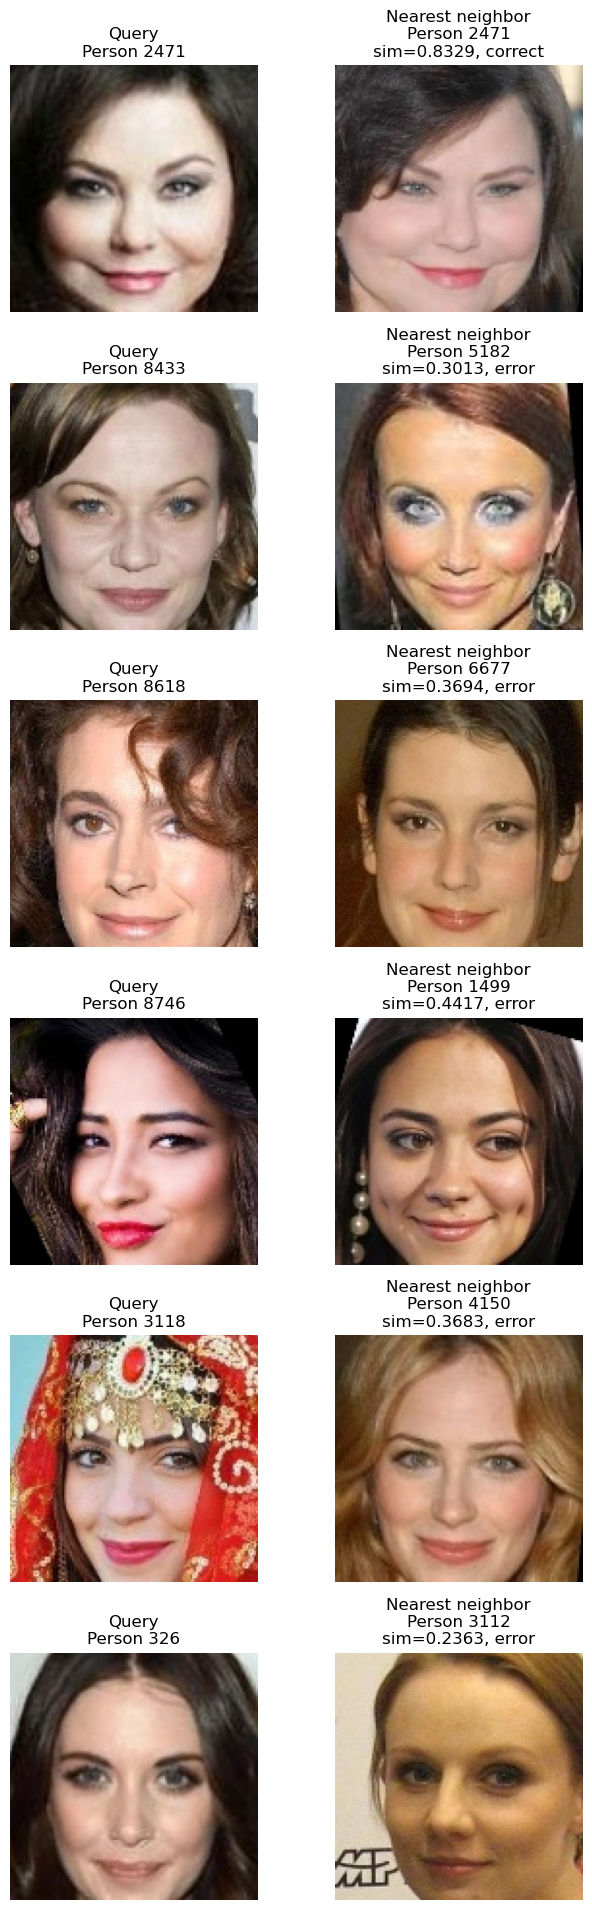

In [13]:
# Визуализация ближайших соседей в пространстве эмбеддингов.
# Для каждого query исключается сравнение изображения с самим собой.

def read_rgb(path):
    """Читает изображение OpenCV и преобразует порядок каналов BGR в RGB."""
    image = cv2.imread(str(path))

    if image is None:
        raise FileNotFoundError(path)

    return cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB,
    )


def show_nearest_neighbor_examples(
    embeddings,
    labels,
    dataframe,
    number_of_examples=6,
    seed=42,
):
    similarities = embeddings @ embeddings.T

    np.fill_diagonal(similarities, -np.inf)

    nearest_indices = np.argmax(similarities, axis=1)

    rng = np.random.default_rng(seed)

    selected_indices = rng.choice(
        np.arange(len(dataframe)),
        size=min(number_of_examples, len(dataframe)),
        replace=False,
    )

    figure, axes = plt.subplots(
        len(selected_indices),
        2,
        figsize=(7, 3.2 * len(selected_indices)),
    )

    if len(selected_indices) == 1:
        axes = np.asarray([axes])

    for row_index, query_index in enumerate(selected_indices):
        neighbor_index = nearest_indices[query_index]

        query_row = dataframe.iloc[query_index]
        neighbor_row = dataframe.iloc[neighbor_index]

        is_correct = labels[query_index] == labels[neighbor_index]

        similarity = similarities[
            query_index,
            neighbor_index,
        ]

        axes[row_index, 0].imshow(
            read_rgb(query_row["image_path"])
        )
        axes[row_index, 0].set_title(
            f"Query\nPerson {query_row['person_id']}"
        )
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(
            read_rgb(neighbor_row["image_path"])
        )
        axes[row_index, 1].set_title(
            f"Nearest neighbor\n"
            f"Person {neighbor_row['person_id']}\n"
            f"sim={similarity:.4f}, "
            f"{'correct' if is_correct else 'error'}"
        )
        axes[row_index, 1].axis("off")

        border_color = "green" if is_correct else "red"

        for spine in axes[row_index, 1].spines.values():
            spine.set_visible(True)
            spine.set_linewidth(4)
            spine.set_edgecolor(border_color)

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "triplet_nearest_neighbor_examples.png",
        dpi=150,
    )

    plt.show()


show_nearest_neighbor_examples(
    embeddings=final_embeddings,
    labels=final_labels,
    dataframe=val_df.reset_index(drop=True),
    number_of_examples=6,
)


## Вывод

Сформирована модель, которая преобразует изображение лица в L2-нормализованный эмбеддинг. Качество оценивается одновременно как задача классификации и как задача поиска ближайшего лица.

Validation Classification Accuracy: 93.51%